In [8]:
import specula
specula.init(0)
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

from specula.lib.modal_base_generator import make_modal_base_from_ifs_fft
from specula.lib.toccd import toccd_gpu


2026-09-28 14:00:28,692 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-09-28 14:00:28,694 [INFO]: [specula]: Default device is GPU number 0


135516


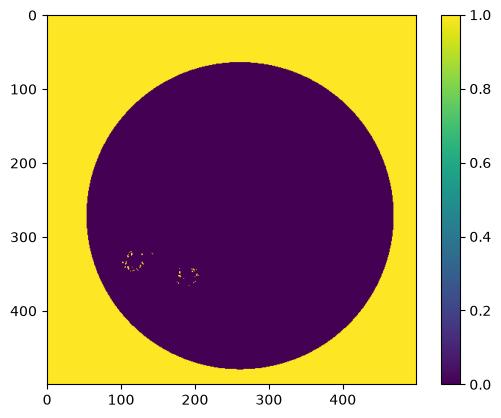

In [2]:
IF = fits.getdata('/raid1/mmenessini/calibration/Cascading/data/influence_functions.fits')

mask = np.zeros(IF.shape[1:])
for i in range(820):
    mask = np.logical_or(mask,np.isnan(IF[i]))

plt.figure()
plt.imshow(mask)
plt.colorbar()

meas_iffs = np.zeros([np.sum(1-mask),820])
for i in range(820):
    meas_iffs[:,i] = IF[i][~mask]

print(np.sum(1-mask))


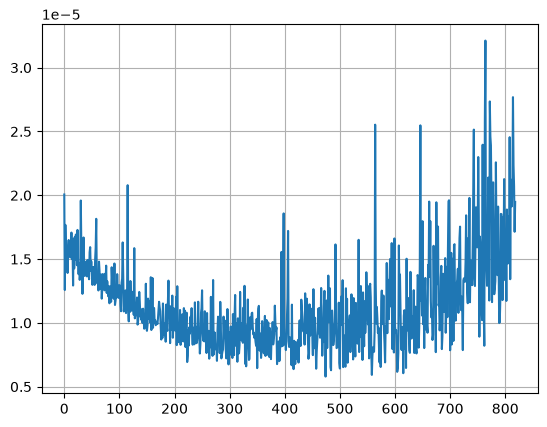

In [3]:
m2c = fits.getdata('/raid1/mmenessini/calibration/SOUL/m2c/simul_s1.0_diam8.0m_m2c.fits')
m2c_ref = fits.getdata('/raid1/mmenessini/calibration/Cascading/data/M2C_20260908_175133.fits')
z2c = fits.getdata('/raid1/mmenessini/calibration/Cascading/data/dm820_z2c.fits')
scale_amps = np.std(meas_iffs@m2c*2,axis=0)

plt.figure()
plt.plot(scale_amps)
plt.grid()

[  0   1   2   3   4   5   6   7   8   9  10  11  21  22  23  24  25  40
  41  42  60  61  83 107 108 133 134 160 161 189 190 219 249 250 280 281
 282 313 314 345 346 377 378 409 410 441 442 473 474 505 506 537 538 568
 569 599 600 629 657 658 685 686 711 712 735 736 757 758 777 778 794 795
 796 797 798 807 808 809 810 811 812 813 814 815 816 817 818 819]


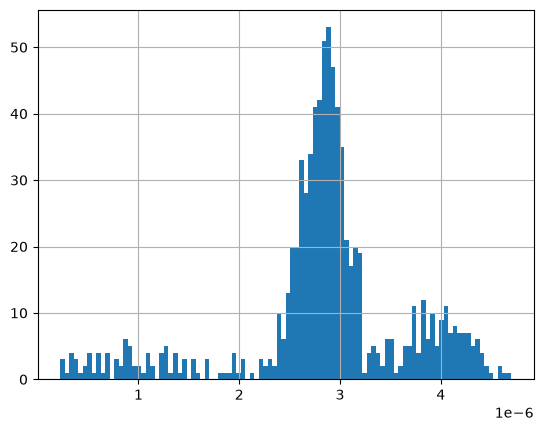

In [4]:
iffs_max = np.max(abs(meas_iffs),axis=0)

plt.figure()
plt.hist(iffs_max,bins=100)
plt.grid()

thr = 2e-6
slave_ids = np.arange(820)[iffs_max <= thr]
print(slave_ids)
master_ids = np.arange(820)[iffs_max > thr]

In [5]:
iffs_master = meas_iffs.T[master_ids]
c_master2z = np.linalg.pinv(z2c[master_ids])
c_master2c_slave = z2c[slave_ids] @ c_master2z
print(iffs_master.shape,c_master2z.shape,c_master2c_slave.shape)

(732, 135516) (200, 732) (88, 732)


In [ ]:
bin_mask = toccd_gpu(specula.xp.array(1-mask).astype(np.float32),(240,240))

bin_iffs = specula.xp.zeros([int(np.sum(bin_mask)),820])
for i in range(820):
    bin_if = toccd_gpu(specula.xp.array(IF[i]),(240,240))
    bin_iffs[:,i] = bin_if[bin_mask.astype(bool)]

ValueError: operands could not be broadcast together with shapes (25963,) (135516,)

In [ ]:
kl_master, m2c_master, _ = make_modal_base_from_ifs_fft(pupil_mask=, diameter=8.0, influence_functions=specula.xp.array(iffs_master), xp=specula.xp,
                                          r0=0.1, L0=25, zern_modes=2, oversampling=4, if_max_condition_number=1e+3, dtype=np.float32)

OutOfMemoryError: Out of memory allocating 5,861,856,256 bytes (allocated so far: 9,205,232,128 bytes).